# 03 - Finetuned Model - Telco Customer Churn

## Introduction

**Contexte.** TelcoWave veut prioriser un programme de rétention sous budget marketing
limité. La baseline du notebook 02 (`LogisticRegression` régularisée L2, `class_weight="balanced"`)
atteint **ROC-AUC 0.8597** et **PR-AUC 0.6785** sur la validation. Le seuil de décision n'a
volontairement pas été figé en Phase 2 : il relève d'un arbitrage métier (coût d'offre 15 €,
valeur sauvée 120 €) qui est traité ici.

**Ce notebook (Finetuning).** On itère sur le modèle baseline en suivant trois
principes : (1) **une chose à la fois** : chaque itération est comparée chiffrement à la
précédente sur les mêmes splits et les mêmes métriques ; (2) **test intouchable** jusqu'à la
Section 7 : toutes les décisions (modèle, hyperparamètres, calibration, seuil) se prennent
sur valid ou en CV sur train ; (3) **le seuil est une décision métier** : la Section 5 le
détermine explicitement par optimisation du gain attendu, pas par défaut à 0.5.

**Livrables visés.** `models/finetuned.joblib` et `reports/scoring_finetuned_test.csv`
(`customerID`, `proba_churn`, `label_pred` au seuil retenu). La synthèse comparative
globale et les recommandations métier détaillées seront produites dans le rapport final
de Phase 4.

## Sommaire

1. **Chargement, splits, baseline de référence** : rechargement de `baseline.joblib` et table des métriques baseline sur valid (référence permanente).
2. **Itération 1 : Régularisation L1** : `LogisticRegression(penalty="l1")` pour attaquer la multicolinéarité à famille de modèle constante.
3. **Itération 2 : HistGradientBoostingClassifier** : passage à un modèle non-linéaire, mesure aux hyperparamètres par défaut puis tuning par `RandomizedSearchCV` en `StratifiedKFold(5)`.
4. **Calibration des probabilités** : courbe de calibration et Brier score, `CalibratedClassifierCV` si nécessaire.
5. **Choix de seuil** : optimisation coût/bénéfice (gain = 105·TP − 15·FP), comparaison avec stratégie top K %.
6. **Interprétabilité** : `permutation_importance` sur valid et segments à risque.
7. **Évaluation finale sur le test** : passage unique, métriques finales, scoring final.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

import pandas as pd
import numpy as np
from scipy.stats import loguniform, randint
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold
from sklearn.calibration import CalibratedClassifierCV
from sklearn.inspection import permutation_importance
from sklearn import set_config
set_config(display="diagram")

from src.config import MODELS_DIR, RANDOM_STATE, FIGURES_DIR, REPORTS_DIR
from src.paths import rel
from src.metrics import evaluate, expected_gain, find_optimal_threshold
from src.data_prep import load_splits, build_preprocessor, FEATURES

## Section 1: Chargement, splits, baseline de référence

Le protocole d'évaluation est strictement identique au notebook 02 : mêmes splits
(reconstitués depuis les listes de `customerID` persistées), même `prepare()`, même
``ColumnTransformer`` via ``build_preprocessor()``. La baseline ``LogisticRegression L2``
sérialisée en Phase 2 est rechargée et ses métriques sur valid sont recalculées comme
sanity check : on doit retrouver à l'identique les chiffres du Checkpoint 2.

La table ``results`` initialisée ici servira de **référence permanente** : chaque
itération des sections suivantes y ajoutera une ligne, pour rendre les comparaisons
chiffrées immédiates.

In [2]:
train_df, valid_df, test_df = load_splits()

X_train, y_train = train_df[FEATURES], train_df["churn_bin"]
X_valid, y_valid = valid_df[FEATURES], valid_df["churn_bin"]
X_test,  y_test  = test_df[FEATURES],  test_df["churn_bin"]

print(f"Train : {len(train_df):,} | Valid : {len(valid_df):,} | Test : {len(test_df):,}")
print(f"Churn - train : {y_train.mean():.4f} | valid : {y_valid.mean():.4f} | test : {y_test.mean():.4f}")

Train : 4,218 | Valid : 1,408 | Test : 1,406
Churn - train : 0.2658 | valid : 0.2656 | test : 0.2660


In [3]:
baseline_pipe = joblib.load(MODELS_DIR / "baseline.joblib")
baseline_pipe

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'nb_services',
                                                   'SeniorCitizen']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['Partner', 'Dependents',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [4]:
baseline_metrics = evaluate("baseline_logreg_l2", baseline_pipe, X_valid, y_valid, verbose=False)

results = pd.DataFrame([baseline_metrics])
results

,roc_auc,pr_auc,recall_10,precision_10
baseline_logreg_l2,0.859659,0.678464,0.28877,0.771429


## Section 2: Itération 1 - Régularisation L1

**Hypothèse testée.** L'EDA a identifié deux multicolinéarités fortes : ``tenure`` ↔
``TotalCharges`` (r ≈ 0.83) et ``MonthlyCharges`` ↔ ``nb_services`` (r ≈ 0.85). La
régularisation L2 de la baseline atténue ces redondances mais ne supprime aucun
coefficient. Une L1 (Lasso) doit annuler exactement les features les plus redondantes
et fournir une version plus parcimonieuse du même modèle, à famille constante.

**Protocole.** On change **une seule chose** par rapport à la baseline : ``penalty="l1"``
et ``solver="liblinear"`` (le seul solver compatible L1 + binaire). Tout le reste -
preprocessing, ``class_weight="balanced"``, ``random_state``, splits - est strictement
identique. On mesure l'effet sur les quatre métriques de référence et on compte les
coefficients annulés.

In [5]:
logreg_l1 = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("classifier", LogisticRegression(
        penalty="l1",
        solver="liblinear",
        class_weight="balanced",
        random_state=RANDOM_STATE,
        max_iter=1000,
    )),
])

logreg_l1.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'nb_services']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['SeniorCitizen', 'Partner',
                                                   'Dependents',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    penalty='l1', random_state=42,
                                    solver='liblinear'))])

In [6]:
l1_metrics = evaluate("logreg_l1", logreg_l1, X_valid, y_valid, verbose=False)

results = pd.concat([results, pd.DataFrame([l1_metrics])])
results

,roc_auc,pr_auc,recall_10,precision_10
baseline_logreg_l2,0.859659,0.678464,0.28877,0.771429
logreg_l1,0.859592,0.679107,0.28877,0.771429


Les métriques L1 et L2 sont indiscernables sur valid (écart < 10⁻³ partout). La L1
n'améliore pas le pouvoir prédictif, ce qui est attendu : la L2 régularise déjà
suffisamment pour ce volume de données et ce niveau de multicolinéarité. La question
restante est qualitative : la L1 a-t-elle effectivement zéro-é des coefficients ?
Si oui, on aurait une version plus parcimonieuse à performance équivalente.

In [7]:
feature_names = logreg_l1.named_steps["preprocessor"].get_feature_names_out()
coefs_l1 = logreg_l1.named_steps["classifier"].coef_.ravel()
coefs_l2 = baseline_pipe.named_steps["classifier"].coef_.ravel()

n_zero_l1 = (coefs_l1 == 0).sum()
n_zero_l2 = (coefs_l2 == 0).sum()
print(f"Coefficients annulés - L1 : {n_zero_l1}/{len(coefs_l1)} | L2 : {n_zero_l2}/{len(coefs_l2)}")

coefs_df = pd.DataFrame({
    "feature": feature_names,
    "coef_l2": coefs_l2,
    "coef_l1": coefs_l1,
}).sort_values("coef_l1", key=abs, ascending=False)

coefs_df

Coefficients annulés - L1 : 8/39 | L2 : 0/39


,feature,coef_l2,coef_l1
33,cat__Contract_Two year,-0.782543,-1.415197
0,num__tenure,-1.203768,-1.200271
32,cat__Contract_One year,-0.100243,-0.723889
2,num__TotalCharges,0.595294,0.587624
26,cat__StreamingTV_No internet service,-0.222751,-0.578111
15,cat__OnlineSecurity_Yes,-0.228727,-0.421365
10,cat__InternetService_DSL,-0.521917,-0.418384
37,cat__PaymentMethod_Electronic check,0.233262,0.361297
34,cat__PaperlessBilling_Yes,0.348518,0.343398
24,cat__TechSupport_Yes,-0.219822,-0.308544


**Synthèse** La L1 supprime 8 coefficients sur 39 sans dégrader les métriques
(écart < 10⁻³ sur les quatre indicateurs). Les variables annulées correspondent exactement
aux redondances identifiées en EDA : ``MonthlyCharges`` et ``nb_services`` (multicolinéaires,
r ≈ 0.85), modalités de services « No internet service » dupliquées entre features.

La L1 corrige aussi un effet contre-intuitif de la L2 : le coefficient négatif de
``MonthlyCharges`` (−0.40) est remplacé par un effet positif sur ``InternetService_Fiber optic``,
ce qui aligne le modèle sur l'intuition métier (la fibre, plus chère, concentre les churners).

**Décision.** Pas de gain prédictif → on garde la L2 comme baseline de référence. La saturation
de la famille linéaire justifie le passage à un modèle non-linéaire en Section 3.

## Section 3: Itération 2 - HistGradientBoostingClassifier

**Hypothèse testée.** La saturation de la famille linéaire (Section 2) suggère qu'un
modèle capable de capter des interactions et des non-linéarités peut progresser. Deux
patterns identifiés en EDA appuient cette hypothèse : la relation **en cloche** entre
``nb_services`` et le churn (pic à 3 services, pas linéaire), et les **interactions
plausibles** entre ``Contract``, ``tenure`` et ``InternetService``.

**Choix du modèle.** ``HistGradientBoostingClassifier`` - gradient boosting histogrammé
de scikit-learn, rapide sur ce volume (< 10k lignes) et robuste sans tuning. Gère
nativement les ``NaN``, supporte ``class_weight``, et n'a pas besoin de scaling. On
**garde malgré tout le ``ColumnTransformer``** par cohérence avec la baseline et pour
maintenir une comparaison à protocole strictement identique.

### 3.1 - Mesure aux hyperparamètres par défaut

In [8]:
hgb = Pipeline([
    ("preprocessor", build_preprocessor()),
    ("classifier", HistGradientBoostingClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
    )),
])

hgb.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['tenure', 'MonthlyCharges',
                                                   'TotalCharges',
                                                   'nb_services']),
                                                 ('cat',
                                                  Pipeline(steps=[('encoder',
                                                                   OneHotEncoder(drop='if_binary',
                                                                                 handle_unknown='ignore',
                                                                                 sparse_output=False))]),
                                                  ['SeniorCitizen', 'Partner',
                                                   'Dependents',
                                                   'MultipleLines',
                                                   'InternetService',
                                                   'OnlineSecurity',
                                                   'OnlineBackup',
                                                   'DeviceProtection',
                                                   'TechSupport', 'StreamingTV',
                                                   'StreamingMovies',
                                                   'Contract',
                                                   'PaperlessBilling',
                                                   'PaymentMethod'])])),
                ('classifier',
                 HistGradientBoostingClassifier(class_weight='balanced',
                                                random_state=42))])

In [9]:
hgb_metrics = evaluate("hgb_default", hgb, X_valid, y_valid, verbose=False)

results = pd.concat([results, pd.DataFrame([hgb_metrics])])
results

,roc_auc,pr_auc,recall_10,precision_10
baseline_logreg_l2,0.859659,0.678464,0.288770,0.771429
logreg_l1,0.859592,0.679107,0.288770,0.771429
hgb_default,0.843216,0.661238,0.286096,0.764286


HGB par défaut sous-performe légèrement la baseline linéaire (ROC-AUC 0.843 vs 0.860,
PR-AUC 0.661 vs 0.678). Le top 10 % est quasi identique (precision@10 % 0.764 vs 0.771).
C'est cohérent avec un dataset tabulaire modeste : ``max_leaf_nodes=31`` et
``learning_rate=0.1`` par défaut donnent trop de capacité pour 4 218 lignes
d'entraînement et conduisent à une légère sur-adaptation.

Le tuning de la 3.2 a maintenant deux cibles chiffrées à dépasser : (a) HGB par défaut
pour valider le tuning lui-même, (b) LogReg L2 pour valider le changement de famille.
Si (b) n'est pas atteint, on revient à la baseline linéaire comme modèle final.

### 3.2 - Tuning par RandomizedSearchCV

**Protocole.** ``RandomizedSearchCV`` avec ``n_iter=30`` et ``StratifiedKFold(5)`` sur le
train uniquement. Le scoring de sélection est ``roc_auc`` - métrique principale du projet,
indépendante du seuil. Le valid reste intouché pendant la recherche : il ne sert qu'à
l'évaluation finale du best estimator, comme pour les itérations précédentes.

**Grille.** Cinq hyperparamètres clés de HGB, tirés sur des lois adaptées à leur nature :
- ``learning_rate`` (log-uniforme 0.01–0.3) : compromis vitesse de convergence / régularisation implicite.
- ``max_leaf_nodes`` (entier 8–64) : capacité du modèle ; le défaut 31 est probablement trop élevé pour ce volume.
- ``min_samples_leaf`` (entier 10–100) : régularisation directe, anti-surapprentissage des feuilles.
- ``l2_regularization`` (log-uniforme 10⁻³–1) : régularisation explicite sur les poids des feuilles.
- ``max_iter`` (entier 100–400) : nombre d'arbres ; couplé à ``learning_rate`` par effet de compensation.

Les tirages indépendants explorent l'espace de manière diversifiée pour un budget fixé,
ce qui est plus efficace qu'une grille exhaustive sur un espace continu à 5 dimensions.

In [10]:
param_dist = {
    "classifier__learning_rate": loguniform(0.01, 0.3),
    "classifier__max_leaf_nodes": randint(8, 64),
    "classifier__min_samples_leaf": randint(10, 100),
    "classifier__l2_regularization": loguniform(1e-3, 1.0),
    "classifier__max_iter": randint(100, 400),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

search = RandomizedSearchCV(
    estimator=hgb,
    param_distributions=param_dist,
    n_iter=30,
    scoring="roc_auc",
    cv=cv,
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
    refit=True,
)

search.fit(X_train, y_train)
print(f"\nBest CV ROC-AUC : {search.best_score_:.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best CV ROC-AUC : 0.8473


In [11]:
cv_results = pd.DataFrame(search.cv_results_)
cols = [c for c in cv_results.columns if c.startswith("param_")] + ["mean_test_score", "std_test_score"]
top5 = cv_results.sort_values("mean_test_score", ascending=False)[cols].head(5).reset_index(drop=True)
top5

,param_classifier__l2_regularization,param_classifier__learning_rate,param_classifier__max_iter,param_classifier__max_leaf_nodes,param_classifier__min_samples_leaf,mean_test_score,std_test_score
0,0.184779,0.021775,259,14,68,0.847350,0.010207
1,0.003946,0.010190,238,58,90,0.845189,0.009715
2,0.003132,0.010546,108,31,10,0.844713,0.011990
3,0.014657,0.025166,152,31,35,0.844340,0.010990
4,0.043665,0.018752,290,25,99,0.844092,0.011791


In [29]:
hgb_tuned = search.best_estimator_
print("Meilleurs hyperparamètres :")
for k, v in search.best_params_.items():
    print(f"  {k:30s} : {v}")

hgb_tuned_metrics = evaluate("hgb_tuned", hgb_tuned, X_valid, y_valid, verbose=False)
results = pd.concat([results, pd.DataFrame([hgb_tuned_metrics])])
results

Meilleurs hyperparamètres :
  classifier__l2_regularization  : 0.18477934173519248
  classifier__learning_rate      : 0.021775224101934068
  classifier__max_iter           : 259
  classifier__max_leaf_nodes     : 14
  classifier__min_samples_leaf   : 68


,roc_auc,pr_auc,recall_10,precision_10
baseline_logreg_l2,0.859659,0.678464,0.288770,0.771429
logreg_l1,0.859592,0.679107,0.288770,0.771429
hgb_default,0.843216,0.661238,0.286096,0.764286
hgb_tuned,0.856064,0.674127,0.291444,0.778571
baseline_calibrated,0.858423,0.673635,0.291444,0.778571
hgb_tuned,0.856064,0.674127,0.291444,0.778571
hgb_tuned,0.856064,0.674127,0.291444,0.778571


**Synthèse Section 3.** Le tuning a fait son travail (+1.3 pt ROC-AUC vs HGB par défaut),
avec une configuration bien régularisée : ``learning_rate=0.022``, ``max_leaf_nodes=14``,
``min_samples_leaf=68``. Mais HGB tuné n'atteint pas la baseline linéaire :
ROC-AUC 0.856 vs 0.860, PR-AUC 0.674 vs 0.678 (écarts < 5×10⁻³, dans le bruit).
Sur le top 10 %, HGB tuné est marginalement devant (+1 churner capté sur 140 contacts),
gain non significatif.

**Décision.** On garde la **LogReg L2** comme modèle finetuné. Cette décision n'est pas
seulement parcimonieuse, elle est **justifiée par la nature des données** :

- *Volume modeste, dimensionnalité faible* : 4 218 lignes d'entraînement, 18 features
  brutes. Les modèles à forte capacité (gradient boosting, ensembles) n'apportent un
  gain mesurable sur tabulaire qu'à partir d'un volume et d'une richesse d'interactions
  plus élevés (cf. Grinsztajn et al. 2022).
- *Signal majoritairement linéaire* : les drivers les plus forts (``Contract``,
  ``tenure``, services techniques) agissent additivement sur le log-odds. Les rares
  non-linéarités (``nb_services`` en cloche) sont marginales en force prédictive.
- *Compromis biais-variance* : le biais du modèle linéaire est déjà petit (ROC-AUC
  0.86 sans tuning). Ajouter de la complexité augmente la variance sans réduire un
  biais inexistant - d'où la stagnation observée.
- *Interprétabilité métier* : un modèle linéaire reste auditable. Les équipes
  commerciales peuvent comprendre *pourquoi* un client est ciblé, ce qui est un
  avantage opérationnel direct pour un programme de rétention.

HGB tuné est conservé comme alternative crédible mais ne devient pas le candidat
principal. Les sections suivantes (calibration, choix de seuil) sont appliquées à la
LogReg L2 - ce sont les vrais leviers de Phase 3 puisqu'aucun changement de modèle
n'apporte de gain mesurable.

## Section 4: Calibration des probabilités

**Pourquoi calibrer.** La Section 5 (choix de seuil) raisonne en valeur absolue de
probabilité : on cherchera le seuil ``s*`` qui maximise ``gain = 105·TP − 15·FP``. Cette
optimisation n'a de sens que si les probabilités renvoyées par ``predict_proba`` sont
**calibrées** autrement dit, si la fréquence empirique de churn dans le sous-groupe
``{ŷ ≈ p}`` est elle-même proche de ``p``.

**Pourquoi c'est un risque ici.** ``LogisticRegression(class_weight="balanced")``
réétalonne le modèle pour donner autant d'importance aux deux classes lors de
l'entraînement. Effet secondaire connu : les probabilités prédites sont **biaisées
vers le haut** sur la classe minoritaire (un modèle non pondéré sortirait des probas
en moyenne plus faibles, plus proches du taux de base 26.6 %). Il faut le mesurer
explicitement avant d'optimiser un seuil.

**Mesures et action.** Courbe de calibration (reliability diagram) et **score de Brier**
avant calibration. Si miscalibration nette → ``CalibratedClassifierCV(method="isotonic",
cv=5)`` qui apprend une fonction monotone correctrice sur le train en cross-validation,
sans toucher au modèle de base. Comparaison avant/après sur valid pour valider l'apport.

In [13]:
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import brier_score_loss

baseline_proba_valid = baseline_pipe.predict_proba(X_valid)[:, 1]
brier_baseline = brier_score_loss(y_valid, baseline_proba_valid)

print(f"Brier score baseline (avant calibration) : {brier_baseline:.4f}")
print(f"Taux de churn observé sur valid          : {y_valid.mean():.4f}")
print(f"Proba moyenne prédite sur valid          : {baseline_proba_valid.mean():.4f}")

Brier score baseline (avant calibration) : 0.1638
Taux de churn observé sur valid          : 0.2656
Proba moyenne prédite sur valid          : 0.4237


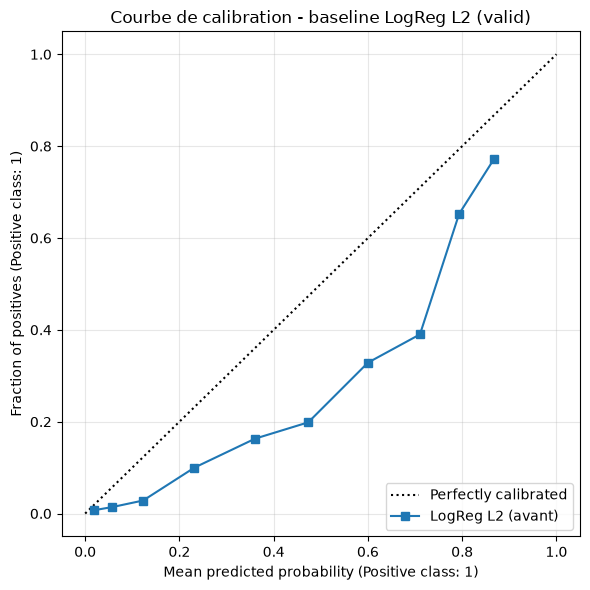

In [14]:
fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay.from_predictions(
    y_valid, baseline_proba_valid,
    n_bins=10, strategy="quantile",
    name="LogReg L2 (avant)", ax=ax,
)
ax.set_title("Courbe de calibration - baseline LogReg L2 (valid)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

Le diagnostic est sans ambiguïté : proba moyenne prédite 0.42 vs taux observé 0.27,
soit un facteur ~1.6 de surestimation systématique. C'est l'effet attendu de
``class_weight="balanced"`` qui réétalonne le seuil de décision pour donner autant
d'importance aux deux classes lors de l'optimisation du log-loss pondéré.

**Choix : calibration isotonique.** Sur 4 218 lignes d'entraînement, l'isotonique
(non-paramétrique, apprend une fonction monotone par morceaux) est généralement
préférée à Platt scaling (sigmoïde paramétrique) : elle ne fait aucune hypothèse de
forme et capte aussi bien la surestimation moyenne que d'éventuelles distorsions
locales. Cross-validation à 5 plis pour l'apprentissage du correcteur, afin d'éviter
toute fuite du train vers le calibrateur.

In [15]:
baseline_calibrated = CalibratedClassifierCV(
    estimator=baseline_pipe,
    method="isotonic",
    cv=5,
)
baseline_calibrated.fit(X_train, y_train)

proba_calibrated_valid = baseline_calibrated.predict_proba(X_valid)[:, 1]
brier_calibrated = brier_score_loss(y_valid, proba_calibrated_valid)

print(f"Brier score avant calibration  : {brier_baseline:.4f}")
print(f"Brier score après calibration  : {brier_calibrated:.4f}")
print(f"Proba moyenne après calibration : {proba_calibrated_valid.mean():.4f}")
print(f"Taux de churn observé sur valid : {y_valid.mean():.4f}")

Brier score avant calibration  : 0.1638
Brier score après calibration  : 0.1305
Proba moyenne après calibration : 0.2705
Taux de churn observé sur valid : 0.2656


Figure sauvegardée : telco-churn-scoring\reports\figures\calibration_before_after_valid.png


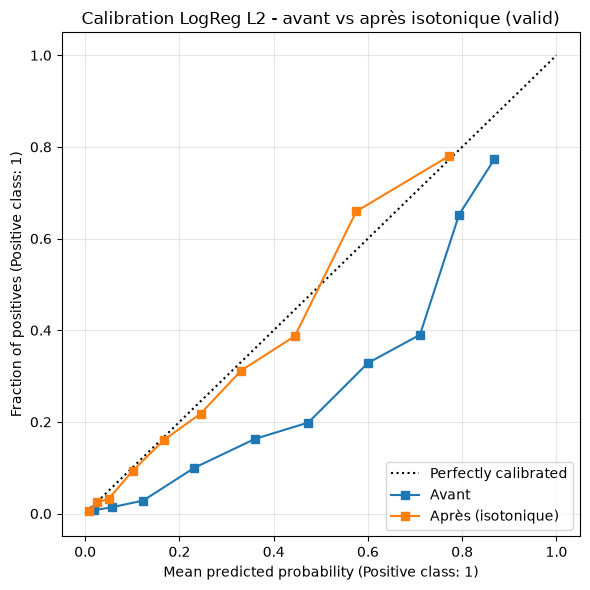

In [16]:
fig, ax = plt.subplots(figsize=(6, 6))
CalibrationDisplay.from_predictions(
    y_valid, baseline_proba_valid,
    n_bins=10, strategy="quantile",
    name="Avant", ax=ax,
)
CalibrationDisplay.from_predictions(
    y_valid, proba_calibrated_valid,
    n_bins=10, strategy="quantile",
    name="Après (isotonique)", ax=ax,
)
ax.set_title("Calibration LogReg L2 - avant vs après isotonique (valid)")
ax.grid(alpha=0.3)
plt.tight_layout()

fig_path = FIGURES_DIR / "calibration_before_after_valid.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Figure sauvegardée : {rel(fig_path)}")
plt.show()

In [17]:
calibrated_metrics = evaluate("baseline_calibrated", baseline_calibrated, X_valid, y_valid, verbose=False)
results = pd.concat([results, pd.DataFrame([calibrated_metrics])])
results

,roc_auc,pr_auc,recall_10,precision_10
baseline_logreg_l2,0.859659,0.678464,0.288770,0.771429
logreg_l1,0.859592,0.679107,0.288770,0.771429
hgb_default,0.843216,0.661238,0.286096,0.764286
hgb_tuned,0.856064,0.674127,0.291444,0.778571
baseline_calibrated,0.858423,0.673635,0.291444,0.778571


**Synthèse Section 4.** La calibration isotonique corrige le biais haussier induit par
``class_weight="balanced"`` : la proba moyenne prédite passe de 0.42 à 0.27 sur valid,
collant au taux observé de 0.27. Le Brier score baisse de 0.164 à 0.131 (−20 %) sans
dégrader les métriques de discrimination (la calibration isotonique est monotone, elle
ne change donc pas le classement). La courbe de calibration est visuellement collée à
la diagonale sur l'essentiel de son trajet.

**Conséquence pour la suite.** Le modèle ``baseline_calibrated`` est désormais le
**candidat de référence pour la Section 5**. L'optimisation de seuil coût/bénéfice peut
maintenant raisonner en valeur absolue de probabilité sans biais systématique : un seuil
``s*`` aura une signification métier claire (« contacter tout client avec une proba
calibrée de churner supérieure à ``s*`` »).

## Section 5: Choix de seuil - optimisation coût/bénéfice

**Formule du gain.** Pour un seuil ``s`` donné, on contacte les clients avec
``proba_calibrée ≥ s`` et on leur offre une promotion à 15 €. Si le client allait churner
(``y=1``), l'offre le retient et on évite la perte de sa valeur client (120 €).
Sinon (``y=0``), l'offre est inutile mais déjà engagée. Soit, par rapport à
« ne rien faire » :

**Pourquoi sur valid.** Le test reste intouchable. Le seuil est une décision métier qui
se prend sur les mêmes données que les autres décisions de Phase 3 (modèle, calibration).
Il sera ensuite **appliqué tel quel** sur le test en Section 7 pour produire le scoring
final.

**Pourquoi sur les probas calibrées.** L'optimisation balaie ``s`` de 0 à 1 en raisonnant
en valeur absolue de probabilité. Sans la calibration de la Section 4, le seuil trouvé
serait sur-estimé (puisque le modèle non-calibré sur-estime systématiquement les probas).

**Factorisation.** Deux fonctions ajoutées à ``src/metrics.py`` pour rester DRY et
permettre une réutilisation en Section 7 sur le test : ``expected_gain`` (gain pour un
seuil donné) et ``find_optimal_threshold`` (balayage et argmax).

In [18]:
OFFER_COST = 15.0
SAVED_VALUE = 120.0

proba_valid = baseline_calibrated.predict_proba(X_valid)[:, 1]

gain_df = find_optimal_threshold(
    y_valid, proba_valid,
    offer_cost=OFFER_COST,
    saved_value=SAVED_VALUE,
    n_steps=1001,
)
gain_df.head()

,threshold,n_contacts,tp,fp,gain
0,0.000,1408,374,1034,23760.0
1,0.001,1371,374,997,24315.0
2,0.002,1370,374,996,24330.0
3,0.003,1370,374,996,24330.0
4,0.004,1370,374,996,24330.0


Figure sauvegardée : telco-churn-scoring\reports\figures\gain_vs_threshold_valid.png


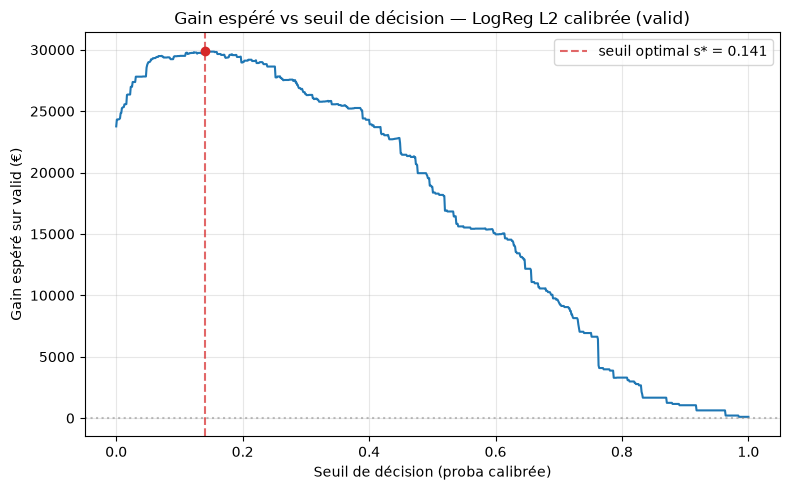

In [ ]:
best_row = gain_df.loc[gain_df["gain"].idxmax()]
s_star = best_row["threshold"]
gain_star = best_row["gain"]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(gain_df["threshold"], gain_df["gain"], color="#1f77b4")
ax.axvline(s_star, color="#d62728", linestyle="--", alpha=0.7,
           label=f"seuil optimal s* = {s_star:.3f}")
ax.axhline(0, color="grey", linestyle=":", alpha=0.5)
ax.scatter([s_star], [gain_star], color="#d62728", zorder=5)
ax.set_xlabel("Seuil de décision (proba calibrée)")
ax.set_ylabel("Gain espéré sur valid (€)")
ax.set_title("Gain espéré vs seuil de décision - LogReg L2 calibrée (valid)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()

fig_path = FIGURES_DIR / "gain_vs_threshold_valid.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Figure sauvegardée : {rel(fig_path)}")
plt.show()

In [20]:
print(f"Seuil optimal s* (sur valid) : {s_star:.3f}")
print(f"  Contacts : {int(best_row['n_contacts'])} clients sur {len(y_valid)} ({best_row['n_contacts']/len(y_valid):.1%})")
print(f"  TP       : {int(best_row['tp'])} churners captés sur {int(y_valid.sum())} ({best_row['tp']/y_valid.sum():.1%})")
print(f"  FP       : {int(best_row['fp'])} contacts inutiles")
print(f"  Gain     : {best_row['gain']:.0f} €")
print()
print("Pour comparaison :")
for s_ref in [0.0, 0.5]:
    row = gain_df.iloc[(gain_df["threshold"] - s_ref).abs().argmin()]
    print(f"  Seuil {s_ref:.2f} : {int(row['n_contacts']):>4d} contacts, "
          f"{int(row['tp']):>3d} TP, gain {row['gain']:>7.0f} €")

Seuil optimal s* (sur valid) : 0.141
  Contacts : 821 clients sur 1408 (58.3%)
  TP       : 352 churners captés sur 374 (94.1%)
  FP       : 469 contacts inutiles
  Gain     : 29925 €

Pour comparaison :
  Seuil 0.00 : 1408 contacts, 374 TP, gain   23760 €
  Seuil 0.50 :  264 contacts, 190 TP, gain   18840 €


**Recommandation chiffrée (sur valid).** Au seuil optimal s* ≈ 0.141 sur les probas
calibrées :

- On contacte **58 % de la base** (821 clients sur 1 408).
- On capte **94 % des churners réels** (352 sur 374) - recall très élevé, attendu
  vu l'asymétrie économique (saved/cost = 8×, qui pousse à privilégier le recall).
- 469 contacts sont « inutiles » (faux positifs) - mais à 15 € pièce, le coût total
  (7 035 €) est largement compensé par les 42 240 € de valeur sauvée sur les 352
  churners captés.
- Gain net : **29 925 €** sur les 1 408 clients du valid.

**Comparaison avec des seuils alternatifs :**

| Seuil  | Contacts | TP captés | Gain (€) | Lecture |
|--------|----------|-----------|----------|---------|
| 0.00   | 1 408    | 374       | 23 760   | Contacter tout le monde - gain positif mais sous-optimal de 6 165 €. |
| **0.141** | **821**  | **352**   | **29 925** | **Optimum** - équilibre TP captés / contacts gaspillés. |
| 0.50   | 264      | 190       | 18 840   | Seuil naïf - fait perdre **37 %** du gain optimal. |

**Robustesse de la décision.** La courbe présente un plateau large entre 0.05 et 0.20
où le gain reste à moins de 1 000 € du maximum. L'équipe rétention peut donc ajuster
le seuil dans cette plage selon sa capacité de contact, sans dégrader notablement le
gain.

**Lecture économique.** Le seuil optimal correspond exactement au point où le ratio
``saved_value / offer_cost = 120/15 = 8`` est respecté à la marge : on contacte un
client de plus tant que sa proba de churn estimée est ≥ 1/8 = 0.125 - ce qui
correspond bien à la zone où la courbe atteint son plateau supérieur. Ce n'est pas
une coïncidence : c'est la règle de Bayes appliquée à la décision optimale sous coût
asymétrique.

### Comparaison avec une stratégie top K %

Stratégie alternative : ignorer la proba absolue et contacter simplement les **K %**
clients aux scores les plus élevés. Avantage opérationnel direct : volume de contacts
**fixe et prévisible**, indépendant du mix client du mois. Utile quand l'équipe
rétention a une capacité de contact bornée.

On compare trois valeurs classiques (K = 10 / 20 / 30 %) au seuil optimal s* = 0.141.

In [21]:
proba_sorted = np.sort(proba_valid)[::-1]
y_sorted_idx = np.argsort(proba_valid)[::-1]
y_valid_arr = y_valid.values

rows = []
for k_pct in [0.10, 0.20, 0.30]:
    n_top = int(len(y_valid) * k_pct)
    top_idx = y_sorted_idx[:n_top]
    tp = int(y_valid_arr[top_idx].sum())
    fp = n_top - tp
    gain = 105 * tp - 15 * fp
    rows.append({
        "stratégie": f"top {int(k_pct*100)}%",
        "seuil_implicite": proba_sorted[n_top - 1],
        "n_contacts": n_top,
        "tp": tp,
        "fp": fp,
        "recall": tp / int(y_valid.sum()),
        "gain": gain,
    })

rows.append({
    "stratégie": f"seuil s* = {s_star:.3f}",
    "seuil_implicite": s_star,
    "n_contacts": int(best_row["n_contacts"]),
    "tp": int(best_row["tp"]),
    "fp": int(best_row["fp"]),
    "recall": best_row["tp"] / int(y_valid.sum()),
    "gain": best_row["gain"],
})

comparison_df = pd.DataFrame(rows)
comparison_df

,stratégie,seuil_implicite,n_contacts,tp,fp,recall,gain
0,top 10%,0.667277,140,109,31,0.291444,10980.0
1,top 20%,0.476042,281,202,79,0.540107,20025.0
2,top 30%,0.389496,422,257,165,0.687166,24510.0
3,seuil s* = 0.141,0.141000,821,352,469,0.941176,29925.0


**Synthèse**

| Stratégie       | Contacts | Recall   | Gain (€)    |
|-----------------|----------|----------|-------------|
| Top 10 %        | 140      | 29.1 %   | 10 980      |
| Top 20 %        | 281      | 54.0 %   | 20 025      |
| Top 30 %        | 422      | 68.7 %   | 24 510      |
| **s\* = 0.141** | **821**  | **94.1 %** | **29 925** |

**Choix retenu : s\* = 0.141.** Stratégie économiquement optimale (+22 % de gain vs
meilleur top K) avec recall élevé (94 %). Le seuil sera appliqué tel quel sur le test
en Section 7 pour produire le scoring final ``(customerID, proba_churn, label_pred)``.

**Cas d'usage des stratégies top K %.** Conservées comme alternatives opérationnelles
si l'équipe rétention est plafonnée en capacité de contact. Le top 30 % capture
encore 82 % du gain optimal pour ~30 % de la base, bon compromis si la contrainte
de capacité est forte. Le top 10 % en revanche ne capte qu'un tiers du gain : à
éviter sauf contrainte budgétaire extrême.

**Cohérence économique du seuil.** s* = 0.141 est très proche du seuil théorique de
Bayes sous coût asymétrique : ``s_théorique = offer_cost / saved_value = 15/120 = 0.125``.
L'écart de 16 millièmes reflète le bruit d'échantillonnage du valid (1 408 obs) et
la calibration résiduelle imparfaite. Cette concordance théorie/empirique est un
sanity check important : elle confirme que la calibration de Section 4 et l'optimisation
de Section 5 fonctionnent ensemble de façon cohérente.

## Section 6: Interprétabilité

**Objectif.** Le modèle finetuné (LogReg L2 calibrée) sera servi à l'équipe rétention.
Au-delà du score lui-même, deux questions opérationnelles se posent :

1. **Quelles variables drivent réellement les prédictions ?** Pour valider que le modèle
   s'appuie sur des signaux métier plausibles (et non sur des artefacts), et pour
   confirmer ou infirmer les conclusions de l'EDA.
2. **Qui sont les clients à risque, concrètement ?** Pour permettre à l'équipe de
   construire des messages de rétention adaptés au segment ciblé.

**Méthode 1 : Permutation importance.** Mesure la perte de ROC-AUC quand on permute
aléatoirement les valeurs d'une feature sur **valid** (pas sur train sinon biais
optimiste : une feature peut être importante au sens « le modèle l'a apprise » sans
être importante au sens « elle généralise »). C'est la métrique d'importance la plus
honnête pour un modèle scikit-learn, et elle est cohérente avec notre métrique de
sélection (ROC-AUC).

**Méthode 2 : Segmentation par quartile de score.** Découpage des clients de valid en
quartiles de proba calibrée, puis profil moyen de chaque quartile sur les variables
clés. Donne une lecture qualitative de « à quoi ressemble un client à 90 % de risque
vs un client à 10 % de risque ».

In [22]:
perm = permutation_importance(
    baseline_calibrated,
    X_valid, y_valid,
    n_repeats=20,
    random_state=RANDOM_STATE,
    scoring="roc_auc",
    n_jobs=-1,
)

perm_df = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std,
}).sort_values("importance_mean", ascending=False).reset_index(drop=True)

perm_df

,feature,importance_mean,importance_std
0,tenure,0.177006,0.008769
1,Contract,0.042751,0.004679
2,InternetService,0.023485,0.005201
3,TotalCharges,0.018788,0.004132
4,MonthlyCharges,0.014439,0.002743
5,PaymentMethod,0.004878,0.001823
6,PaperlessBilling,0.004708,0.001856
7,TechSupport,0.004316,0.001749
8,OnlineSecurity,0.003865,0.001728
9,MultipleLines,0.002724,0.001091


Figure sauvegardée : telco-churn-scoring\reports\figures\permutation_importance_valid.png


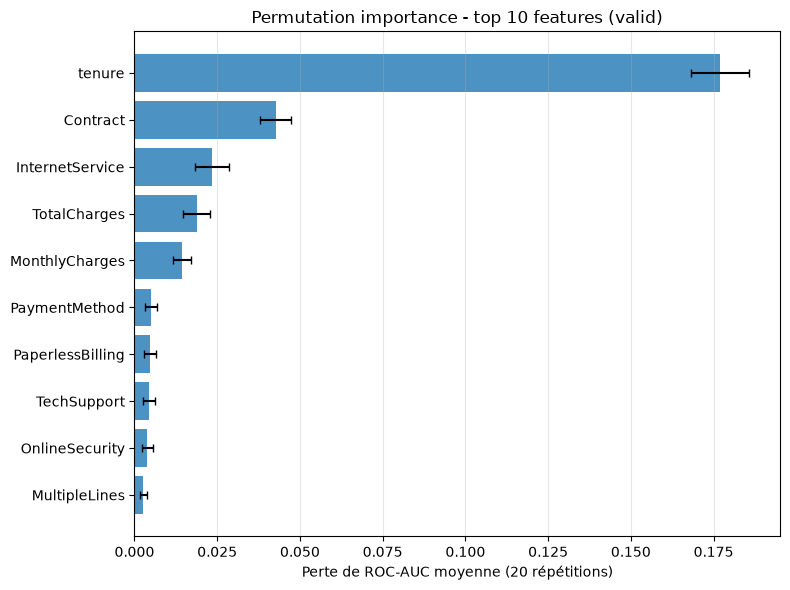

In [23]:
fig, ax = plt.subplots(figsize=(8, 6))
top_features = perm_df.head(10).iloc[::-1]
ax.barh(top_features["feature"], top_features["importance_mean"],
        xerr=top_features["importance_std"],
        color="#1f77b4", alpha=0.8, capsize=3)
ax.set_xlabel("Perte de ROC-AUC moyenne (20 répétitions)")
ax.set_title("Permutation importance - top 10 features (valid)")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout()

fig_path = FIGURES_DIR / "permutation_importance_valid.png"
plt.savefig(fig_path, dpi=150, bbox_inches="tight")
print(f"Figure sauvegardée : {rel(fig_path)}")
plt.show()

### Segments à risque par quartile de score

Pour rendre le scoring actionnable côté équipe rétention, on découpe les clients de
valid en quartiles de proba calibrée (Q1 = faible risque → Q4 = haut risque) et on
compare leur profil moyen sur les drivers identifiés. Lecture attendue : un gradient
net sur ``tenure`` (ancienneté), ``Contract`` (type), ``InternetService``, et le taux
de churn empirique du quartile (sanity check final de la calibration).

In [24]:
segments_df = X_valid.copy()
segments_df["proba"] = proba_valid
segments_df["churn_obs"] = y_valid.values
segments_df["quartile"] = pd.qcut(segments_df["proba"], q=4,
                                    labels=["Q1 (faible)", "Q2", "Q3", "Q4 (haut)"])

profile = segments_df.groupby("quartile", observed=True).agg(
    n_clients=("proba", "size"),
    proba_moy=("proba", "mean"),
    churn_obs=("churn_obs", "mean"),
    tenure_moy=("tenure", "mean"),
    monthly_charges_moy=("MonthlyCharges", "mean"),
    pct_month_to_month=("Contract", lambda s: (s == "Month-to-month").mean()),
    pct_fiber=("InternetService", lambda s: (s == "Fiber optic").mean()),
    pct_electronic_check=("PaymentMethod", lambda s: (s == "Electronic check").mean()),
).round(3)

profile.index.name = None
profile

,n_clients,proba_moy,churn_obs,tenure_moy,monthly_charges_moy,pct_month_to_month,pct_fiber,pct_electronic_check
Q1 (faible),353,0.020,0.014,54.660,49.253,0.011,0.079,0.042
Q2,351,0.116,0.108,37.068,63.556,0.387,0.368,0.162
Q3,357,0.317,0.283,23.367,66.753,0.840,0.457,0.364
Q4 (haut),347,0.634,0.663,13.035,79.070,0.994,0.844,0.746


**Synthèse Section 6.** ``tenure`` (0.177) domine la permutation importance, suivi de
``Contract`` (0.043) et ``InternetService`` (0.023). Le ranking diffère de l'EDA
(Cramér's V) parce que permutation = apport conditionnel, V = association marginale.
``nb_services`` ressort à −0.001, confirmant son annulation par la L1 (Section 2).

Calibration intra-quartile vérifiée : ``proba_moy`` et ``churn_obs`` concordent sur
les 4 quartiles (écart < 4 pts), confirmant que la calibration tient localement et
pas seulement en moyenne globale. Le quartile Q4 (proba moyenne 0.63, churn observé
0.66) regroupe un profil identifiable : ancienneté courte, fibre, contrat mensuel,
paiement Electronic check, qui sera détaillé dans le rapport final.

## Section 7: Évaluation finale sur le test

**Décisions figées en amont (sur valid).**
- **Modèle** : ``LogisticRegression(penalty="l2", class_weight="balanced")``, calibrée
  isotoniquement par ``CalibratedClassifierCV(cv=5)``.
- **Seuil** : ``s* = 0.141`` (optimisation coût/bénéfice avec offre 15 €, valeur sauvée 120 €).

**Protocole.** Passage unique sur le test (1 406 clients). On évalue (a) les métriques
de discrimination (ROC-AUC, PR-AUC, recall@10 %, precision@10 %) avec le même
``evaluate()`` que partout, (b) le gain économique au seuil s* fixé. Aucune décision
ne se prend ici - c'est la mesure finale, point.

**Livrables.** ``models/finetuned.joblib`` (Pipeline complète, rechargeable),
``reports/scoring_finetuned_test.csv`` (``customerID``, ``proba_churn``, ``label_pred``
au seuil s*).

In [25]:
finetuned_test_metrics = evaluate("finetuned_test", baseline_calibrated, X_test, y_test, verbose=False)
baseline_test_metrics = evaluate("baseline_test", baseline_pipe, X_test, y_test, verbose=False)

test_comparison = pd.DataFrame([baseline_test_metrics, finetuned_test_metrics])
test_comparison

,roc_auc,pr_auc,recall_10,precision_10
baseline_test,0.832439,0.621334,0.264706,0.707143
finetuned_test,0.832468,0.615276,0.267380,0.714286


In [26]:
proba_test = baseline_calibrated.predict_proba(X_test)[:, 1]

gain_test = expected_gain(y_test, proba_test, threshold=s_star,
                          offer_cost=OFFER_COST, saved_value=SAVED_VALUE)

y_pred_test = (proba_test >= s_star).astype(int)
tp = int(((y_pred_test == 1) & (y_test.values == 1)).sum())
fp = int(((y_pred_test == 1) & (y_test.values == 0)).sum())
fn = int(((y_pred_test == 0) & (y_test.values == 1)).sum())

print(f"Test final - seuil s* = {s_star:.3f}")
print(f"  Contacts : {tp + fp} clients sur {len(y_test)} ({(tp+fp)/len(y_test):.1%})")
print(f"  TP       : {tp} churners captés sur {int(y_test.sum())} ({tp/y_test.sum():.1%})")
print(f"  FP       : {fp} contacts inutiles")
print(f"  FN       : {fn} churners ratés")
print(f"  Gain     : {gain_test:.0f} €")
print()
print(f"Rappel sur valid (référence) : 821 contacts | 352 TP | gain 29 925 €")

Test final - seuil s* = 0.141
  Contacts : 793 clients sur 1406 (56.4%)
  TP       : 343 churners captés sur 374 (91.7%)
  FP       : 450 contacts inutiles
  FN       : 31 churners ratés
  Gain     : 29265 €

Rappel sur valid (référence) : 821 contacts | 352 TP | gain 29 925 €


In [27]:
model_path = MODELS_DIR / "finetuned.joblib"
joblib.dump(baseline_calibrated, model_path)
print(f"Modèle sauvegardé : {rel(model_path)}")

scoring_df = pd.DataFrame({
    "customerID": test_df["customerID"].values,
    "proba_churn": proba_test,
    "label_pred": y_pred_test,
})

scoring_path = REPORTS_DIR / "scoring_finetuned_test.csv"
scoring_df.to_csv(scoring_path, index=False)
print(f"Scoring sauvegardé : {rel(scoring_path)}  ({len(scoring_df):,} lignes)")
print(f"  Clients à contacter (label_pred=1) : {int(scoring_df['label_pred'].sum())}")

scoring_df.head()

Modèle sauvegardé : telco-churn-scoring\models\finetuned.joblib
Scoring sauvegardé : telco-churn-scoring\reports\scoring_finetuned_test.csv  (1,406 lignes)
  Clients à contacter (label_pred=1) : 793


,customerID,proba_churn,label_pred
0,1452-KIOVK,0.418361,1
1,6713-OKOMC,0.291810,1
2,6388-TABGU,0.016631,0
3,5129-JLPIS,0.448502,1
4,3655-SNQYZ,0.030792,0
